In [13]:

from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

In [14]:

# Load dataset
diabetes = load_diabetes()

# Feature matrix
X = diabetes.data

# Target (disease progression)
y = diabetes.target

# Use only BMI feature
X = X[:, 2].reshape(-1, 1)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 1)
y shape: (442,)


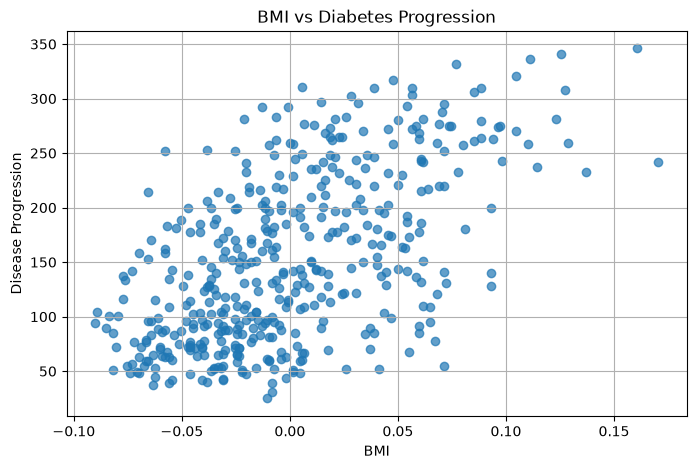

In [15]:

plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    alpha=0.7
)

plt.title("BMI vs Diabetes Progression")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")

plt.grid(True)
plt.show()

In [16]:
tree1 = DecisionTreeRegressor(max_depth = 3)

tree1.fit(X,y)

pred1 = tree1.predict(X)

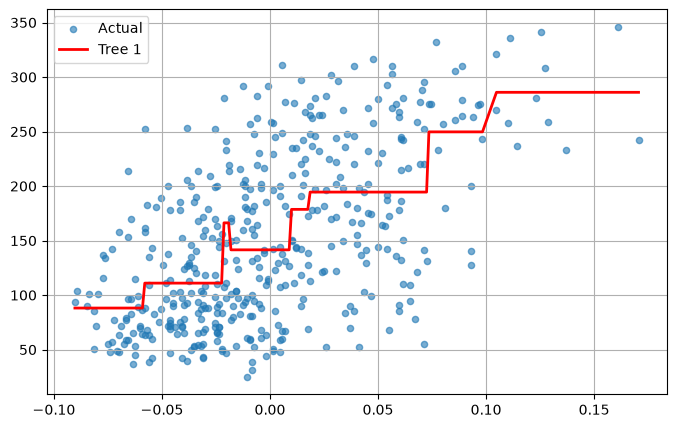

In [17]:

plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    s=20,
    alpha=0.6,
    label="Actual"
)

order = np.argsort(X[:,0])

plt.plot(
    X[order],
    pred1[order],
    color="red",
    linewidth=2,
    label="Tree 1"
)

plt.legend()
plt.grid(True)
plt.show()

In [18]:
residual1 = y - pred1

print(residuall1[:10])

[-43.5        -36.         -53.5         64.47524752  24.
 -14.          27.         -78.52475248 -84.5        115.5       ]


In [19]:
tree2 = DecisionTreeRegressor(max_depth=2)

tree2.fit(X, residual1)

pred2 = tree2.predict(X)

In [20]:
learning_rate = 0.1

boosted_prediction = pred1 + learning_rate * pred2

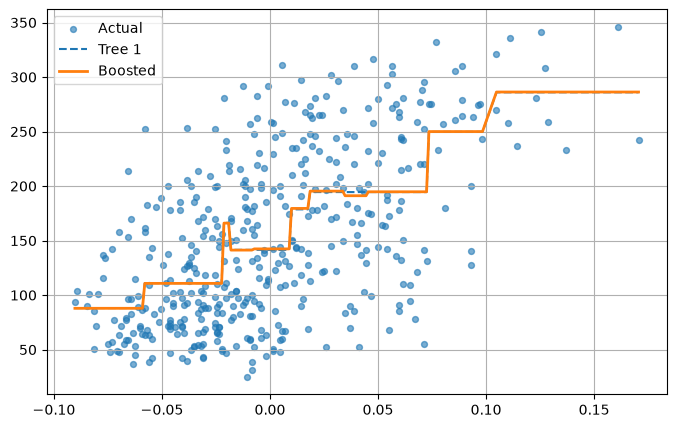

In [21]:

plt.figure(figsize=(8,5))

plt.scatter(
    X,
    y,
    s=18,
    alpha=0.6,
    label="Actual"
)

plt.plot(
    X[order],
    pred1[order],
    "--",
    label="Tree 1"
)

plt.plot(
    X[order],
    boosted_prediction[order],
    linewidth=2,
    label="Boosted"
)

plt.legend()
plt.grid(True)
plt.show()

In [22]:
class GradientBoosting:

    def __init__(self,n_estimators=50,learning_rate=0.1,max_depth=2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth

        self.trees = []

    def fit(self,X,y):
        prediction = np.zeros(len(y))

        for _ in range(self.n_estimators):

            residual = y - prediction

            tree = DecisionTreeRegressor(max_depth = self.max_depth)

            tree.fit(X,residual)

            prediction += (self.learning_rate * tree.predict(X))

            self.trees.append(tree)

    def predict(self,X):

        prediction = np.zeros(len(X))

        for tree in self.trees:
            prediction += (self.learning_rate * tree.predict(X))

        return prediction

In [23]:
model = GradientBoosting(n_estimators= 100, learning_rate= 0.1,max_depth=2)

model.fit(X,y)

y_pred = model.predict(X)

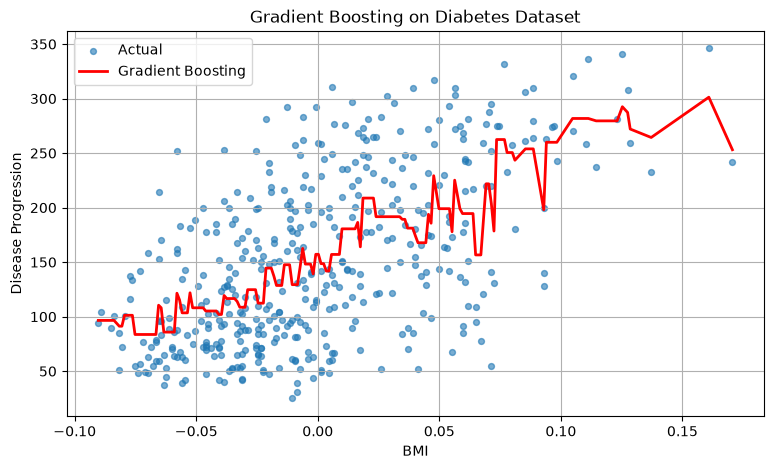

In [24]:

plt.figure(figsize=(9,5))

plt.scatter(
    X,
    y,
    s=18,
    alpha=0.6,
    label="Actual"
)

plt.plot(
    X[order],
    y_pred[order],
    color="red",
    linewidth=2,
    label="Gradient Boosting"
)

plt.title("Gradient Boosting on Diabetes Dataset")

plt.xlabel("BMI")
plt.ylabel("Disease Progression")

plt.legend()
plt.grid(True)
plt.show()

In [25]:
rmse = np.sqrt(np.mean((y - y_pred)**2))

print(f"RMSE: {rmse:.2f}")

RMSE: 56.50
